# 06 — Neighborhood Calibration: the San Fernando Valley

**Question this notebook answers:** *Does lived experience of the Valley match what the data suggests?*

This is a calibration exercise, not discovery: before the first field visits, we pin the data's view of neighborhoods we know personally, so that when we stand on a corner we can tell whether the data lied, the intuition lied, or both. The output is a comparison table, a set of calibration prompts, and the **field program** (chronic hotspots + Valley revisit sites + clean comparisons).

## Geography mapping

The dataset's finest reliable geography is the Neighborhood Council. Colloquial neighborhoods ≠ NC boundaries, so we map explicitly — and note the seams:

| Neighborhood | NC(s) used | Seam notes |
|---|---|---|
| Van Nuys | VAN NUYS NC | core Van Nuys; Lake Balboa & Valley Glen are separate NCs, excluded |
| Panorama City | PANORAMA CITY NC | — |
| Sherman Oaks | SHERMAN OAKS NC | — |
| Studio City | STUDIO CITY NC | — |
| Encino | ENCINO NC | — |
| North Hollywood | NOHO NC + NOHO WEST NC + NORTH HOLLYWOOD NORTH EAST NC | three NCs cover colloquial NoHo |
| Reseda | RESEDA NC | included — it kept forcing itself into every prior notebook |

## Filters & method

Standard operational filter (standards §1), Jan–Jun 2026. Places = 20m clusters computed **citywide** (same pipeline as notebook 05 — a place near an NC boundary is still one place), then attributed to neighborhoods by their reports' NC field. Duration metrics: cases created before June 1, LASAN track only (holding the two-track split of F15 constant — LSD share is reported separately).

## On normalization

Raw report counts mislead: these NCs differ several-fold in size and population, and we have no population/road-mile data joined yet (logged as future work). We therefore compare **structure, not volume**:
- **dumping share of the neighborhood's own 311 demand** (self-normalizing: the neighborhood is its own denominator), expressed as a ratio to the citywide 28.8%;
- **recurring vs one-off share** of dumping reports;
- **hotspot intensity** (reports per recurring place, and count of chronic 25+ places);
- operational quality (median close, gone-on-arrival rate, LSD share).

One warning learned while building this: the *share* metric can be gamed by the denominator — Downtown LA shows a low dumping share only because its 311 demand is flooded with encampment reports. Share must always be read next to intensity.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN

raw = pd.read_csv(Path("../data/raw/myla311_cases_2026.csv"), low_memory=False)

INTAKE_ARTIFACTS = {"Information-Only", "Feedback", "Program Research"}
DEAD_STATUSES = {"Cancelled", "Potential Duplicate", "Duplicate Confirm"}
DUP_CODES = ("DUP-", "B-Duplicated", "CDR-")

def standard_operational_filter(df):
    """Standard filter per docs/analysis_standards.md section 1."""
    out = df[~df["RequestType"].isin(INTAKE_ARTIFACTS)]
    out = out[~out["Status"].isin(DEAD_STATUSES)]
    out = out[~out["ResolutionCode"].fillna("").str.startswith(DUP_CODES)]
    return out

op = standard_operational_filter(raw).copy()
op["created"] = pd.to_datetime(op["CreatedDate"], format="mixed")
op = op[op["created"] < "2026-07-01"]

NEIGH = {
    "Van Nuys": ["VAN NUYS NC"],
    "Panorama City": ["PANORAMA CITY NC"],
    "Sherman Oaks": ["SHERMAN OAKS NC"],
    "Studio City": ["STUDIO CITY NC"],
    "Encino": ["ENCINO NC"],
    "North Hollywood": ["NOHO NC", "NOHO WEST NC", "NORTH HOLLYWOOD NORTH EAST NC"],
    "Reseda": ["RESEDA NC"],
}
NC_TO_NEIGH = {nc: n for n, ncs in NEIGH.items() for nc in ncs}
op["neigh"] = op["NCName"].map(NC_TO_NEIGH)

# citywide 20m places (same pipeline as notebook 05)
il = op[op["RequestType"] == "Illegal Dumping Item Pickup"].dropna(subset=["Latitude", "Longitude"])
il = il[il["Latitude"].between(33.60, 34.40) & il["Longitude"].between(-118.75, -118.10)]
g = gpd.GeoDataFrame(
    il, geometry=gpd.points_from_xy(il["Longitude"], il["Latitude"]), crs="EPSG:4326"
).to_crs("EPSG:32611")
g["place"] = DBSCAN(eps=20, min_samples=1).fit_predict(np.c_[g.geometry.x, g.geometry.y])
place_size = g["place"].map(g["place"].value_counts())
g["recurring"] = place_size >= 2
g["neigh"] = g["NCName"].map(NC_TO_NEIGH)

CITYWIDE_SHARE = len(il) / len(op)
print(f"citywide baselines: dumping share {CITYWIDE_SHARE:.1%} | recurring share {g['recurring'].mean():.1%}")

citywide baselines: dumping share 28.8% | recurring share 81.1%


In [2]:
def neighborhood_profile(name):
    o = op[op["neigh"] == name]
    d = g[g["neigh"] == name]
    lasan_closed = d[(d["Status"] == "Closed") & (d["created"] < "2026-06-01")
                     & d["Owner"].isin(["LASAN", "Sanitation"])]
    days = (pd.to_datetime(lasan_closed["ClosedDate"], format="mixed")
            - lasan_closed["created"]).dt.total_seconds() / 86400
    places = d.groupby("place").size()
    share = len(d) / len(o)
    return {
        "311 demand": len(o),
        "dumping reports": len(d),
        "dumping share %": round(share * 100, 1),
        "share vs citywide": round(share / CITYWIDE_SHARE, 2),
        "% at recurring places": round(d["recurring"].mean() * 100, 1),
        "reports per recurring place": round(places[places >= 2].mean(), 1),
        "places 10+": int((places >= 10).sum()),
        "chronic places 25+": int((places >= 25).sum()),
        "median days to close (LASAN)": round(days.median(), 1),
        "% gone on arrival": round((d["ResolutionCode"] == "QC-Item Not Out").mean() * 100, 1),
        "% LSD-serviced": round(d["Owner"].isin(["LSD", "LASAN - LSD"]).mean() * 100, 1),
    }

table = pd.DataFrame({n: neighborhood_profile(n) for n in NEIGH})
table

,Van Nuys,Panorama City,Sherman Oaks,Studio City,Encino,North Hollywood,Reseda
311 demand,18275.0,8798.0,13422.00,8070.00,8885.00,27344.00,14004.00
dumping reports,8406.0,3289.0,3164.00,1373.00,1989.00,10952.00,4511.00
dumping share %,46.0,37.4,23.60,17.00,22.40,40.10,32.20
share vs citywide,1.6,1.3,0.82,0.59,0.78,1.39,1.12
% at recurring places,89.4,82.2,80.60,74.80,81.50,83.80,82.20
reports per recurring place,6.1,4.8,4.20,3.90,5.70,4.60,5.10
places 10+,209.0,55.0,38.00,21.00,44.00,181.00,81.00
chronic places 25+,31.0,4.0,4.00,0.00,7.00,16.00,16.00
median days to close (LASAN),2.9,3.7,2.40,2.70,1.80,2.70,2.70
% gone on arrival,28.3,35.6,32.30,35.70,33.30,26.40,27.20


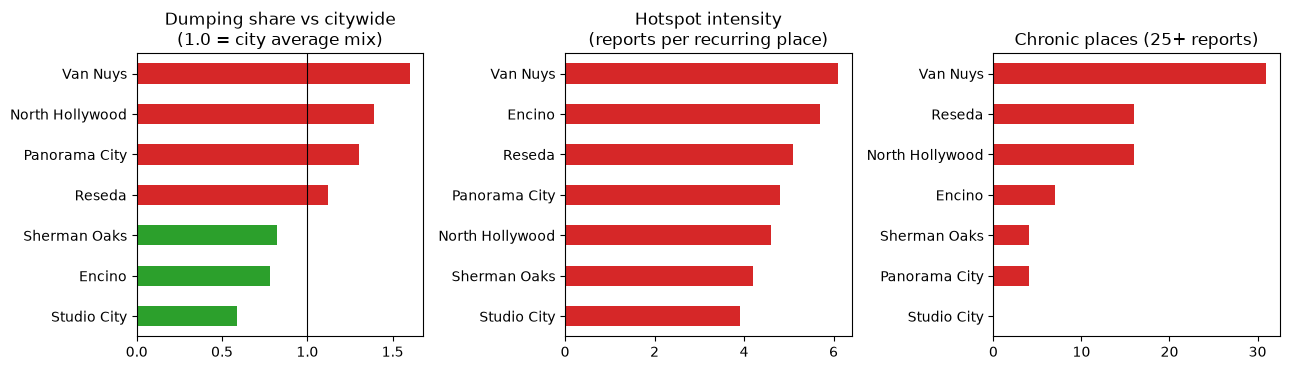

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

ratio = table.loc["share vs citywide"].astype(float).sort_values()
colors = ["tab:red" if v > 1 else "tab:green" for v in ratio]
ratio.plot(kind="barh", ax=axes[0], color=colors)
axes[0].axvline(1, color="k", lw=0.8)
axes[0].set_title("Dumping share vs citywide\n(1.0 = city average mix)")

intensity = table.loc["reports per recurring place"].astype(float).sort_values()
intensity.plot(kind="barh", ax=axes[1], color="tab:red")
axes[1].set_title("Hotspot intensity\n(reports per recurring place)")

chronic = table.loc["chronic places 25+"].astype(float).sort_values()
chronic.plot(kind="barh", ax=axes[2], color="tab:red")
axes[2].set_title("Chronic places (25+ reports)")
plt.tight_layout()

## Reading the comparison

**Van Nuys is the Valley's dumping capital — and it's not close.** Dumping is **46% of everything Van Nuys reports to 311** (1.6x the citywide mix), with the Valley's highest intensity (6.1 reports per recurring place) and 31 chronic sites. Whatever residents feel about Van Nuys and trash: the data says it's not imagination.

**North Hollywood is a volume giant with an encampment component.** Largest absolute counts here (10.9K dumping reports across its three NCs, 40% of local demand), 16 chronic sites, and the Valley's highest LSD share (20% — encampment-adjacent servicing concentrated around the NoHo core and Lankershim).

**Panorama City punches above its size but *fails differently*.** 37% dumping share, only 4 chronic sites — but the Valley's **slowest closures (3.7d median vs 1.8–2.9 elsewhere) and a 36% gone-on-arrival rate**. Reports there more often end with nothing collected. Whether that's crew allocation, reporting behavior, or scavenging economics is a field/interview question.

**Reseda is a corridor phenomenon.** Overall structure looks moderate (1.12x, 16 chronic sites) — but its top three places are **all on Sherman Way within a half-mile** (17900: 78 reports, 17808: 53, 17940: 45). The NC-level view *understates* Reseda; the corridor view is the true unit.

**Sherman Oaks and Encino run below the citywide mix (0.82x / 0.78x) — but Encino hides pockets.** Encino has **7 chronic 25+ sites** (more than Sherman Oaks's 4 and Studio City's 0) clustered on specific residential-adjacent streets (Yarmouth, Newcastle, White Oak — all just off the Ventura corridor), *and* the Valley's fastest closures (1.8d). Low background, sharp spikes.

**Studio City is the clean control.** Lowest share (17%, 0.59x), lowest recurring share (75%), lowest intensity (3.9), **zero chronic 25+ places**. Its top place (Arch Dr, 22 reports) wouldn't crack Van Nuys's top fifteen.

Direct structural comparison — recurring vs one-off: every neighborhood sits within a few points of the citywide 81% recurring share (Studio City lowest at 75%, Van Nuys highest at 89%). **Recurrence is not a "bad neighborhood" trait; it is the universal structure of dumping.** What varies between neighborhoods is *how many* chronic places exist and *how intense* they get — not whether dumping recurs.

## Does the data match my intuition?

The data's claims, phrased as testable expectations — mark each true/false against lived experience (and file the reactions as the first entry in `field-notes/`):

1. Van Nuys should *feel* like the Valley's dumping center — especially the blocks around Delano St / Erwin St west of Van Nuys Blvd, and Sherman Way. (46% share, top intensity)
2. NoHo's problem should feel concentrated around Lankershim and the eastern (91605) blocks, with visible encampment entanglement. (20% LSD share)
3. Panorama City piles should seem to "disappear on their own" more often than elsewhere. (36% gone-on-arrival)
4. Reseda should feel fine as a neighborhood but Sherman Way between ~17800–17950 should be visibly, chronically bad. (corridor concentration)
5. Sherman Oaks and Studio City should feel meaningfully cleaner than the Van Nuys border zones — with the transition noticeable within a few blocks around the Magnolia/Burbank Blvd line. (0.82x / 0.59x vs 1.60x)
6. Encino should mostly feel clean but with a few specific streets that residents privately know as problem spots. (7 chronic pockets on low background)

Where intuition disagrees with any of these, that disagreement is *the finding* — either a reporting-bias artifact worth chasing (quiet ≠ clean) or a data artifact worth debugging.

## Which neighborhoods deserve field visits?

**Van Nuys** (the phenomenon at full strength, in familiar territory), **Reseda's Sherman Way corridor** (corridor dynamics + 3 chronic sites in walking distance), **Panorama City** (the gone-on-arrival anomaly), and **NoHo's Lankershim spine** (encampment-adjacent archetype). Encino's pockets are a bonus half-day (chronic sites inside a clean background — the sharpest possible contrast over a short drive).

## Which neighborhoods should serve as "clean" comparison cases?

**Studio City** first (clean by every structural measure, adjacent to Van Nuys for same-day contrast), **Sherman Oaks' Ventura corridor** second. Citywide clean candidates are computed in the field program below.

## What surprised us?

- **Studio City's zero.** Not merely below average — *no* chronic 25+ site at all, uniquely among the seven.
- **Encino's seven chronic pockets** despite a below-citywide share: "clean neighborhood" and "chronic dumping sites" coexist comfortably.
- **Panorama City's failure mode is different in kind** — slowest closes and highest gone-on-arrival, despite moderate chronic-site count. Neighborhoods don't just differ in *how much* dumping; they differ in *how the service system performs*.
- Recurring share barely varies (75–89%) across neighborhoods spanning 0.59x–1.60x demand mix — recurrence is structural, everywhere.

## What should we investigate in person?

1. The **Van Nuys ↔ Studio City gradient**: drive Van Nuys Blvd → Ventura Blvd; where exactly does the street character flip, and does it match the NC boundary or a land-use line?
2. **Sherman Way, Reseda, 17800–17950 blocks**: is this one continuous condition (storefront alleys? vacant frontage?) or three distinct spots?
3. **Panorama City gone-on-arrival**: visit 2–3 sites shortly after new reports appear; is material being scavenged, moved, or was it never there?
4. **Encino's pockets** (Yarmouth/Newcastle/White Oak): what physical feature makes these specific blocks the exception inside a clean area?
5. At every stop: land use, alley vs curb frontage, lighting, cameras, signage, bin access, encampment proximity — the checklist from notebook 05.

---

# Field Program

## A. Citywide chronic hotspots — top 10 to visit regardless of distance

In [4]:
g_sorted = g.sort_values(["place", "created"])
med_gap = g_sorted.groupby("place")["created"].apply(
    lambda s: s.diff().dt.total_seconds().median() / 86400 if len(s) > 1 else np.nan)

def mode_or_blank(s):
    s = s.dropna()
    return s.mode().iloc[0] if len(s) else ""

place_stats = g.groupby("place").agg(
    reports=("place", "size"),
    address=("Address", mode_or_blank),
    neighborhood=("NCName", mode_or_blank),
    council_district=("CD", mode_or_blank),
    months_active=("created", lambda s: s.dt.month.nunique()),
    lsd_share=("Owner", lambda s: s.isin(["LSD", "LASAN - LSD"]).mean()),
    gone_on_arrival=("ResolutionCode", lambda s: (s == "QC-Item Not Out").mean()),
)
place_stats["median_gap_days"] = med_gap
place_stats["last_report"] = g.groupby("place")["created"].max()

def why(r):
    notes = []
    if (pd.Timestamp("2026-06-30") - r["last_report"]).days > 45:
        notes.append(f"WENT QUIET {r['last_report']:%b %d} after heavy activity - intervention?")
    if r["lsd_share"] >= 0.5:
        notes.append("encampment-adjacent (LSD)")
    if r["gone_on_arrival"] >= 0.3:
        notes.append(f"{r['gone_on_arrival']:.0%} gone-on-arrival")
    if r["median_gap_days"] is not None and r["median_gap_days"] <= 1:
        notes.append("sub-daily report gaps")
    elif r["median_gap_days"] is not None and r["median_gap_days"] <= 2.5:
        notes.append("refills every 1-2 days")
    return "; ".join(notes) if notes else "high-volume chronic site"

citywide10 = place_stats[place_stats["months_active"] >= 4].nlargest(10, "reports").copy()
citywide10["why_interesting"] = citywide10.apply(why, axis=1)
A = citywide10.reset_index(drop=True).round({"median_gap_days": 1, "lsd_share": 2, "gone_on_arrival": 2})
A.index += 1
A[["address", "neighborhood", "council_district", "reports", "median_gap_days", "why_interesting"]]

,address,neighborhood,council_district,reports,median_gap_days,why_interesting
1,4TH ST and NEW HAMPSHIRE AVE,WILSHIRE CENTER - KOREATOWN NC,10.0,115,0.4,WENT QUIET Apr 17 after heavy activity - inter...
2,"350 N AVENUE 21, LOS ANGELES, CA, 90031",LINCOLN HEIGHTS NC,1.0,78,1.0,encampment-adjacent (LSD); refills every 1-2 days
3,"17900 SHERMAN WAY, LOS ANGELES, CA, 91335",RESEDA NC,4.0,78,1.3,refills every 1-2 days
4,"8142 PERSHING DR, LOS ANGELES, CA, 90293",WESTCHESTER/PLAYA NC,11.0,76,0.0,sub-daily report gaps
5,"1431 N HOBART BLVD, LOS ANGELES, CA, 90027",EAST HOLLYWOOD NC,13.0,73,1.1,refills every 1-2 days
6,"114 S NEW HAMPSHIRE AVE, LOS ANGELES, CA, 90004",WILSHIRE CENTER - KOREATOWN NC,10.0,73,0.9,sub-daily report gaps
7,"1342 S ELWOOD ST, LOS ANGELES, CA, 90021",DOWNTOWN LOS ANGELES,14.0,65,0.5,encampment-adjacent (LSD); sub-daily report gaps
8,"1201 W 39TH PL, LOS ANGELES, CA, 90037",EMPOWERMENT CONGRESS NORTH AREA NC,8.0,63,2.0,refills every 1-2 days
9,"345 COLUMBIA AVE, LOS ANGELES, CA, 90017",WESTLAKE NORTH NC,1.0,63,1.4,32% gone-on-arrival; refills every 1-2 days
10,GRAMERCY PL and GAGE AVE,EMPOWERMENT CONGRESS CENTRAL AREA NC,8.0,60,2.0,refills every 1-2 days


Ten sites, three archetypes (per notebook 05): encampment-adjacent anchors (4th & New Hampshire, 350 N Avenue 21, Elwood St, Lankershim), resident/commercial refill corners (114 S New Hampshire, W 39th Pl, Columbia Ave, Gramercy & Gage), and the standing puzzles — Pershing Dr (Westchester: 76 reports *in a low-dumping district*, burst re-reporting) and 17900 Sherman Way (the Reseda corridor anchor, doubling as a Valley target below).

**And one discovery made while assembling this list: the citywide #1 site went dark.** 4th St & New Hampshire Ave logged 115 reports between Jan 1 and Apr 17 (27, 34, 35 by month, ~one report every 1.5 days) — then **zero reports for the final 2.5 months** of the period. It is 100% LSD-serviced, so an encampment resolution (Inside Safe operation? posted CARE+ schedule change? physical site alteration?) is the leading hypothesis. **This makes it the single highest-value visit on the list**: if something at that corner *worked*, we want to know what it was — and whether the demand migrated to a nearby corner (114 S New Hampshire, 400m south, remained active through June).

## B. San Fernando Valley field targets — revisit sites for the project's duration

In [5]:
valley_places = g[g["neigh"].notna()].groupby("place").size()
vp = place_stats.loc[place_stats.index.isin(valley_places.index)].copy()
vp["neigh"] = g.groupby("place")["neigh"].agg(mode_or_blank)

# top site per neighborhood first (coverage), then fill to 9 by report count
picks = vp.sort_values("reports", ascending=False).groupby("neigh").head(1)
rest = vp.drop(picks.index).nlargest(9 - len(picks), "reports")
B = pd.concat([picks, rest]).sort_values("reports", ascending=False)
B["why_selected"] = B.apply(why, axis=1) + "; " + B["neigh"].map({
    "Van Nuys": "Valley dumping capital",
    "North Hollywood": "encampment-adjacent archetype",
    "Reseda": "Sherman Way corridor",
    "Panorama City": "gone-on-arrival anomaly area",
    "Encino": "chronic pocket inside clean background",
    "Sherman Oaks": "moderate-area top site",
    "Studio City": "clean-area top site (ceiling check)",
})
B = B.reset_index(drop=True).round({"median_gap_days": 1, "lsd_share": 2, "gone_on_arrival": 2})
B.index += 1
B[["address", "neigh", "reports", "median_gap_days", "why_selected"]]

,address,neigh,reports,median_gap_days,why_selected
1,"17900 SHERMAN WAY, LOS ANGELES, CA, 91335",Reseda,78,1.3,refills every 1-2 days; Sherman Way corridor
2,"5767 LANKERSHIM BLVD, LOS ANGELES, CA, 91601",North Hollywood,60,1.6,encampment-adjacent (LSD); refills every 1-2 d...
3,"14102 DELANO ST, LOS ANGELES, CA, 91401",Van Nuys,58,2.1,31% gone-on-arrival; refills every 1-2 days; V...
4,"17808 SHERMAN WAY, LOS ANGELES, CA, 91335",Reseda,53,2.8,high-volume chronic site; Sherman Way corridor
5,"13036 SHERMAN WAY, LOS ANGELES, CA, 91605",North Hollywood,46,2.5,encampment-adjacent (LSD); encampment-adjacent...
6,"5130 YARMOUTH AVE, LOS ANGELES, CA, 91316",Encino,37,3.5,high-volume chronic site; chronic pocket insid...
7,"9404 VAN NUYS BLVD, LOS ANGELES, CA, 91402",Panorama City,35,5.5,high-volume chronic site; gone-on-arrival anom...
8,"14359 ADDISON ST, LOS ANGELES, CA, 91423",Sherman Oaks,26,3.4,high-volume chronic site; moderate-area top site
9,"4176 ARCH DR, LOS ANGELES, CA, 91604",Studio City,22,6.3,high-volume chronic site; clean-area top site ...


Selection rule: the top site in *each* of the seven neighborhoods (coverage — including Studio City's modest ceiling, which calibrates what "clean-area worst" looks like), then the remaining slots filled by report count (which adds the second Reseda corridor block and Van Nuys's Erwin St). These are deliberately *revisitable*: all are within a short drive of each other, so a single loop can sample the full range from 78-report chronic to 22-report clean-area-max.

## C. Clean comparison sites

In [6]:
nc_table = op.groupby("NCName").size().rename("op_demand").to_frame()
nc_table["dumping"] = g.groupby("NCName").size()
nc_table = nc_table.fillna(0)
nc_table["dump_share_%"] = (nc_table["dumping"] / nc_table["op_demand"] * 100).round(1)
nc_places = g.groupby("NCName")["place"].apply(lambda s: (s.value_counts() >= 25).sum())
nc_table["chronic_places_25+"] = nc_places
clean = nc_table[nc_table["op_demand"] >= 4000].sort_values("dump_share_%").head(10)
clean

,op_demand,dumping,dump_share_%,chronic_places_25+
NCName,,,,
PORTER RANCH NC,4005,210,5.2,0
BEL AIR-BEVERLY CREST NC,5835,319,5.5,0
WESTLAKE SOUTH NC,10808,1071,9.9,2
GRANADA HILLS NORTH NC,4908,571,11.6,1
WOODLAND HILLS-WARNER CENTER NC,13376,1677,12.5,4
NORTHRIDGE WEST NC,4228,618,14.6,0
WEST HILLS NC,8631,1310,15.2,0
DOWNTOWN LOS ANGELES,20996,3204,15.3,13
GRANADA HILLS SOUTH NC,8064,1280,15.9,0


Chosen comparison sites (share read *together with* chronic-place count, per the DTLA warning — Downtown's low share is a denominator artifact and it is excluded):

1. **Studio City — Ventura Blvd (Laurel Canyon ↔ Coldwater)**: 0.59x share, zero chronic places, *inside* the study area — the primary control, one boundary away from Van Nuys.
2. **Woodland Hills–Warner Center**: a major commercial center with high overall 311 engagement (13.4K cases — people report plenty) yet only a 12.5% dumping share. High civic voice + low dumping = the cleanest fair comparison for commercial corridors.
3. **Porter Ranch**: the citywide minimum (5.2%) among engaged NCs — master-planned suburb; useful as the "what does near-zero look like" anchor, with the caveat that its built form (HOA, no alleys, low renter share) explains as much as any city service does.
4. **Granada Hills North (11.6%)**: single-family Valley fabric demographically closer to Reseda/Northridge than Porter Ranch — a fairer "ordinary but clean" Valley control.
5. **Sherman Oaks — Ventura corridor**: 0.82x, low intensity; the *gradient* case — same boulevard, changing conditions, 2km from Van Nuys's worst blocks.

Why these "perform well," per the data: all combine below-mix dumping share, few or no chronic places, *and* healthy overall 311 usage (so quiet-≠-clean bias is partially controlled — these communities demonstrably do report things). What the data *cannot* say is why: built form, income, alley presence, enforcement, private hauling. That's exactly what visiting them alongside the chronic sites is for.

In [7]:
A_out = A.assign(section="A_citywide")
B_out = (B.drop(columns=["neighborhood"])
           .rename(columns={"neigh": "neighborhood", "why_selected": "why_interesting"})
           .assign(section="B_valley"))
program = pd.concat([
    A_out[["section", "address", "neighborhood", "council_district", "reports",
           "median_gap_days", "lsd_share", "gone_on_arrival", "why_interesting"]],
    B_out[["section", "address", "neighborhood", "reports",
           "median_gap_days", "lsd_share", "gone_on_arrival", "why_interesting"]],
])
program.to_csv("../data/processed/field_program_nb06.csv", index=False)
print(f"saved field program: {len(program)} target sites -> data/processed/field_program_nb06.csv")
print("(clean comparison sites are corridors/areas, not points - listed in markdown above)")

saved field program: 19 target sites -> data/processed/field_program_nb06.csv
(clean comparison sites are corridors/areas, not points - listed in markdown above)
